# 01 — H1 intimacy audit (human review)

What kind of intimacy does each candidate topic actually contain? This notebook reads
**saved** Pass A/B/C outputs and evidence packets only (no OpenRouter). Rating cells stay
blinded (`CELL_*`).

Everything so far in Stage 11 that touched H1 was a code attached to a topic id. Here the
check is the same one Stage 10 NB07 made for taxonomy leaves: **does the prose read the
way the code says it should?**

Evidence is not cherry-picked. Packets were built once (keywords + high-confidence
sentences); Pass A scores lexical cues, Pass B scores sentences, Pass C adjudicates.
Close-reading below always includes disagreements / mixed / manual-review topics, then a
stratified sample so large pools stay readable.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("01_h1_intimacy_audit")
cfg = ctx.cfg
HYP = "H1"
CODE_COL = "intimacy_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/01_h1_intimacy_audit


## 1. Which topics were audited, and how are they coded?

Overview shows **topic id — label** and **taxonomy id — name** for every H1-coded topic.
The question to keep in mind while reading: is this kissing / affection / explicit sex /
something else — or a mix the old `2.3` leaf would have collapsed?

In [2]:
master = nh.load_master(cfg)
h1 = master[master[CODE_COL].notna()].copy()
h1["code_norm"] = h1[CODE_COL].map(normalize_code)
print(f"H1-coded topics: {len(h1)}")

overview = rd.annotation_overview(h1, CODE_COL)
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]])
ctx.save_table(overview, "h1_topic_overview_labeled")

print("\nCode mass (raw → normalised):")
display(h1[CODE_COL].value_counts().rename("n").to_frame())
display(h1["code_norm"].value_counts(dropna=False).rename("n_norm").to_frame())

H1-coded topics: 98


,topic,taxonomy,code,code_norm,mixed,agree
0,58 — Coping With A Damaged Limb,"1.2 — Pain, Injury & Physical Vulnerability",I0,I0,False,H1
1,57 — Hands Raised in Reassuring Gesture,1.7 — Facial Expression & Non-Sexual Nonverbal...,I0,I0,False,
2,11 — Eyes Meeting Across The Room,2.1 — Attraction & Sexual Tension,I10,I10,False,H1
3,19 — Legs Wrapped Around His Waist,2.1 — Attraction & Sexual Tension,I3,I3,False,H1
4,25 — Crawling Onto The Bed Together,2.1 — Attraction & Sexual Tension,I0,I0,False,
...,...,...,...,...,...,...
93,82 — Touch Her and Your Family Suffers,"7.2 — Violence, Threats & Non-Sexual Coercion",MIXED,None,True,
94,199 — Shoved to His Knees,7.4 — Unwanted or Coercive Sexual Contact,I0,I0,False,
95,345 — Older Man Trading Shelter For Sex,7.4 — Unwanted or Coercive Sexual Contact,I9,I9,False,H1
96,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,MIXED,None,True,H2


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/01_h1_intimacy_audit/tables/h1_topic_overview_labeled.csv  (98 rows)

Code mass (raw → normalised):


,n
intimacy_code,
I0,33
I2,28
MIXED,9
I4,7
I10,5
I3,4
I8,4
I6,3
I1,2


,n_norm
code_norm,
I0,33
I2,28
None,9
I4,7
I10,5
I3,4
I8,4
I6,3
I1,2


## 2. Lexical vs contextual agreement

Pass A never sees sentences; Pass B never sees the public label. Disagreement is the
interesting case — it usually means keywords and prose pull in different directions.

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h1, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    rate = agree["agree"].mean()
    print(
        f"Lexical–contextual agreement: {rate:.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h1_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]].copy()
    print(f"Disagreements to read first: {len(disagree)}")
    display(
        disagree[
            ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_a", "rationale_b"]
        ].head(40)
    )
else:
    print("No Pass A/B rows loaded.")

Lexical–contextual agreement: 55.1% (54/98)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/01_h1_intimacy_audit/tables/h1_lexical_contextual_agreement.csv  (98 rows)
Disagreements to read first: 44


,topic,taxonomy,code_a,code_b,code_c,rationale_a,rationale_b
0,1 — Straps Sliding Down Her Arms,2.3 — Explicit Sexual Acts,I6,MIXED,MIXED,"Main keywords (kiss, kissed, lips, kisses, kis...",The topic spans a wide range of intimacy funct...
2,7 — Kissing With Tongue and Urgency,2.3 — Explicit Sexual Acts,I6,I3,MIXED,All four representations converge on I6. Main ...,"The majority of sentences depict kissing, hold..."
6,25 — Crawling Onto The Bed Together,2.1 — Attraction & Sexual Tension,I3,I0,I0,"Main keywords (snuggled, lay, bed, pillow) ind...",The majority of sentences (12/20) describe pos...
7,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",I5,I1,I1,"Main keywords ('love, loved, loves, falling, f...",Every sentence in this topic consists exclusiv...
12,41 — Gripping Her Neck and Pulling Close,2.3 — Explicit Sexual Acts,I6,MIXED,MIXED,"Main keywords 'kissed, lips, kiss, mouth, tong...",The topic spans a spectrum from affectionate n...
19,57 — Hands Raised in Reassuring Gesture,1.7 — Facial Expression & Non-Sexual Nonverbal...,I5,I0,I0,All four keyword lists center on body-language...,All sentences in this topic describe hand and ...
21,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,I5,MIXED,MIXED,All four keyword lists center on jewelry (ring...,The topic centers on jewelry in a romance cont...
22,62 — Admitting You've Been Stupid,"4.5 — Reconciliation, Commitments & HEA",I7,I0,I0,All keyword lists converge on verbal conflict ...,All sentences in this topic revolve around exp...
27,82 — Touch Her and Your Family Suffers,"7.2 — Violence, Threats & Non-Sexual Coercion",I6,MIXED,MIXED,Main contains explicit genital/oral terms (coc...,The topic clusters around the word 'touch' use...
30,86 — First Name Used at Last,4.2 — Ongoing Courtship & Everyday Relational ...,I2,I0,I0,All keyword sets converge on a scene of identi...,All sentences in this topic revolve exclusivel...


## 3. Old taxonomy leaf vs new intimacy code

Where does the Stage 09 leaf assignment land after functional re-coding? A leaf that
splinters across many intimacy codes is a measurement failure worth quoting from below.

,taxonomy,current_taxonomy_id,code_norm,n
27,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,I2,21
18,4.2 — Ongoing Courtship & Everyday Relational ...,4.2,I0,12
26,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,I0,9
6,2.1 — Attraction & Sexual Tension,2.1,I4,6
3,2.1 — Attraction & Sexual Tension,2.1,I10,5
16,"2.5 — Sexual Negotiation, Safety Preparation &...",2.5,I8,4
23,"4.5 — Reconciliation, Commitments & HEA",4.5,I0,4
25,"4.5 — Reconciliation, Commitments & HEA",4.5,I2,3
9,2.2 — Kissing & Non-Explicit Affection,2.2,I3,3
12,2.3 — Explicit Sexual Acts,2.3,I6,3


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/01_h1_intimacy_audit/tables/h1_taxonomy_vs_code.csv  (33 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/01_h1_intimacy_audit/figures/h1_code_distribution.png


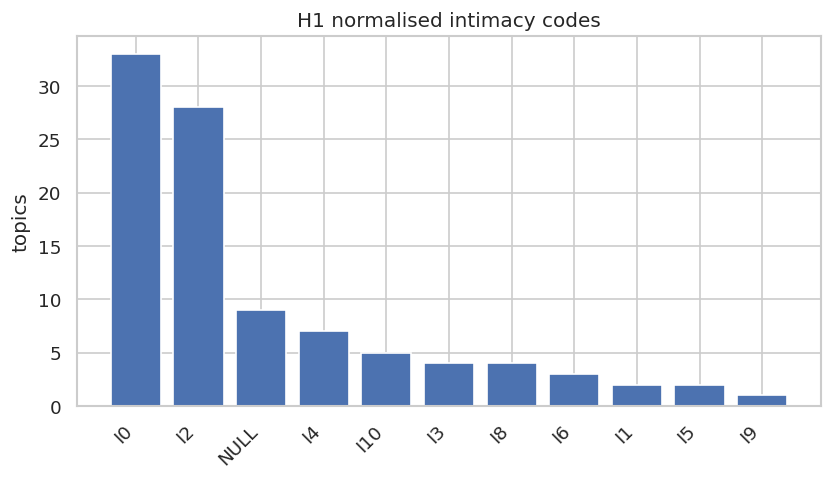

In [4]:
cross = (
    h1.assign(
        taxonomy=h1.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        )
    )
    .groupby(["taxonomy", "current_taxonomy_id", "code_norm"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(cross.head(40))
ctx.save_table(cross, "h1_taxonomy_vs_code")

fig, ax = plt.subplots(figsize=(8, 4))
vc = h1["code_norm"].fillna("NULL").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H1 normalised intimacy codes")
ax.set_ylabel("topics")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h1_code_distribution")
plt.show()

## 4. Close reading

For each selected topic: keywords, Stage-08 snippets, novel sentences (blinded cell /
anon book), and Pass A/B/C rationales. What would falsify the assigned code? Prose that
is mostly dialogue tags, setting, or non-intimate action under an intimacy label —
or explicit genital content still coded as light affection.

In [5]:
review_ids = rd.select_review_topics(
    h1,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h1,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H1 intimacy — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h1[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "intimacy_code",
            "code_norm",
            "mixed_topic",
            "lexical_context_agreement",
        ]
    ],
    "intimacy_topic_annotations",
)

Close-reading 74 of 98 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 1 — Straps Sliding Down Her Arms
  Taxonomy : 2.3 — Explicit Sexual Acts
  Code     : MIXED
  Stage08 snippets:
      · i’ve had practice,” he said as he slid the straps down my arms and removed it.
      · how could a man who just serenaded me with one of the sexiest songs i’ve ever heard
      · and who kisses the way he does be a virgin?
      · the way he holds me —the tenderness, the carefulness—gives me hope that we’ve made
      · great strides tonight.
  Novel sentences:
    · [BOOK_002, CELL_A, tertile=begin, p=0.84]
        His hand came up to grip my head, keeping me trapped in the loving softness of his
        kiss.
    · [BOOK_002, CELL_A, tertile=middle, p=0.84]
        His lips attached to my neck as his fingers worked their way up my shirt.
    · [BOOK_002, CELL_A, tertile=end, p=0.82]
        He held me to him as his mouth moved in sync with mine, his tongue just slipping in
 

### What to take from the cards

- Prefer Pass C when A and B disagree, but only if the sentences support it.
- `MIXED` / `SPLIT` topics should not enter a single strict intimacy weight without a
  secondary construct — check whether the prose really is two scenes glued together.
- No rating effects are examined here; that wait until notebooks 09–11.

print("H1 audit review complete. Tables + close_reading_pack.md written.")